# 1.- Configuration:

* **Name:** StevoAngel
* **Assigned Model:** XCEPTION.
* **Dataset name:** *casting product image data for quality inspection*
* **Dataset source:** https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product

## 1.2.- Dataset description:

### 1.2.1.- Purpose and Context:
Casting is a process where liquid metal is poured into molds. Defects often arise (porosity, burrs, shrinkage, etc.) that must be detected. This dataset aims to train a classification model that distinguishes between defective parts (def_front) and parts in good condition (ok_front).

### 1.2.2.- Dataset composition:
The dataset is presented in two main formats, captured under controlled lighting conditions to ensure consistency:
Data with Augmentation (300x300 px):
- Total: 7,348 grayscale images.
- Status: They already include data augmentation techniques to improve training.
- Original Data (512x512 px):
    - Total: 1,300 grayscale images (without augmentation).
    - Distribution: 519 images of OK parts and 781 of defective parts.

### 1.2.3.- Dataset division:
To facilitate the development of the model, the data is already divided into training (train) and testing (test) folders:
| Set | Defective (def_front) | In good condition (ok_front) |
| :--- | :--- | :--- |
| **Training** | 3,758 images | 2,875 images |
| **Testing** | 453 images | 262 images |


# 2.- Imports and reproducibility

In [1]:
# Used libraries:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import random

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from collections import Counter
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Random seed to ensure reproducibility:
def set_seed(seed=42):
    # 1. Native python seed:
    random.seed(seed)

    # 2. Evironment python seed:
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Numpy seed:
    np.random.seed(seed)
    
    # 4. PyTorch seed (CPU)
    torch.manual_seed(seed)
    
    # 5. PyTorch seed (GPU / CUDA)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas múltiples GPUs
    
    # 6. CuDNN deterministic for stability in math operations:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) # Call seed function

# Version of PyTorch:
print(f"Versión de PyTorch: {torch.__version__}")

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Versión de PyTorch: 2.10.0+cu130


# 3.- Loading the data:

In [2]:
# Locations of datasets:
train_path = '../data/raw/casting_data/train'
test_path = '../data/raw/casting_data/test'

# Counting the number of elements
for path in [train_path, test_path]:
    print(f"\nUbicación: {path}")
    for clase in sorted(os.listdir(path)):
        ruta_clase = os.path.join(path, clase)
        if os.path.isdir(ruta_clase):
            print(f"{clase}: {len(os.listdir(ruta_clase))} imágenes")


Ubicación: ../data/raw/casting_data/train
def_front: 3758 imágenes
ok_front: 2875 imágenes

Ubicación: ../data/raw/casting_data/test
def_front: 453 imágenes
ok_front: 262 imágenes


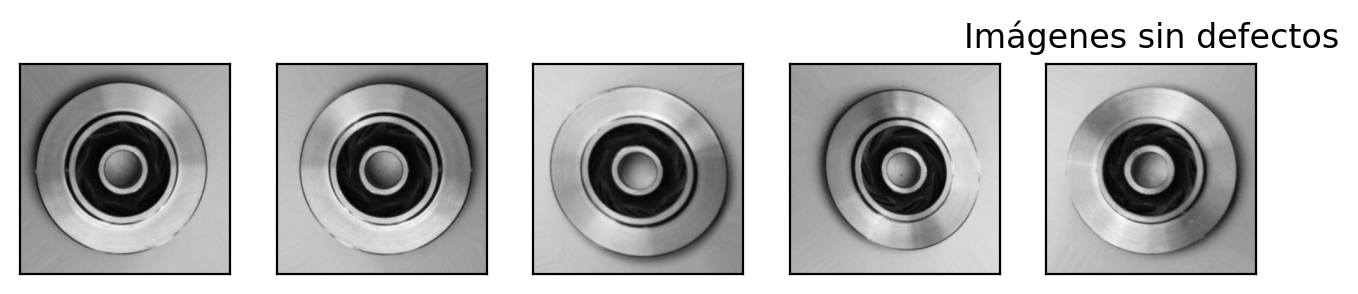

In [3]:
# Visual examples of dataset:
dataset_path_norm = os.path.join(train_path, "ok_front") # Path to GOOD images dataset
dataset_path_def  = os.path.join(train_path, "def_front") # Path to DEFECT images dataset

imgs_norm = os.listdir(os.path.join(dataset_path_norm)) # GOOD images
imgs_def  = os.listdir(os.path.join(dataset_path_def))  # DEFECT images

random.seed(42)

# Randomly sample 5 images per category:
samples_norm = random.sample(imgs_norm, 5)
samples_def  = random.sample(imgs_def, 5)

fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range(len(samples_norm)):
    ax = plt.subplot(2, 5, i + 1)
    imgNormPlot = Image.open(os.path.join(dataset_path_norm, samples_norm[i]))
    plt.imshow(imgNormPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.title("Imágenes sin defectos", loc='center')
plt.show()

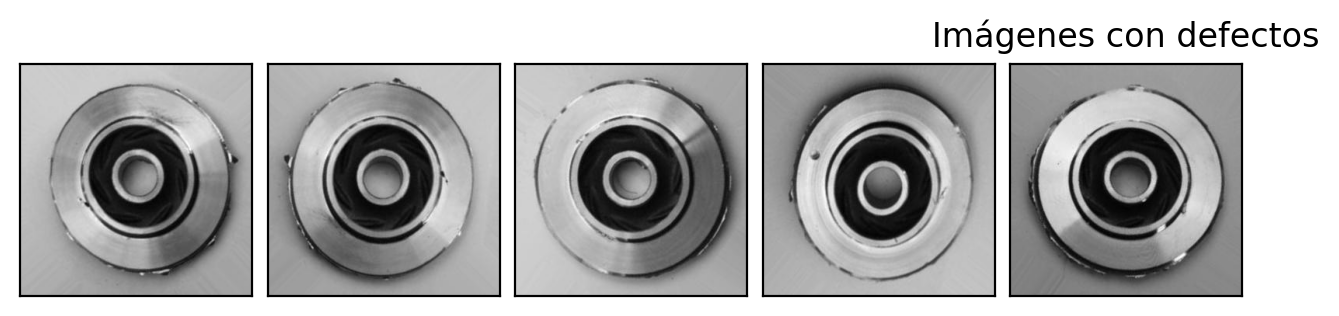

In [4]:
fig = plt.figure(dpi=200, figsize=(8, 3))

for i in range (len(samples_def)):
    ax = plt.subplot(2, 5, i + 6)
    imgDefPlot = Image.open(os.path.join(dataset_path_def, samples_def[i]))
    plt.imshow(imgDefPlot, cmap='gray')
    plt.xticks([])
    plt.yticks([])

plt.subplots_adjust(wspace=-0.01, hspace=-0.01)

plt.title("Imágenes con defectos")
plt.show()

In [5]:
# Showing dimensions of input images:
sample_image = '../data/raw/casting_data/train/ok_front/cast_ok_0_1.jpeg'

with Image.open(sample_image) as img:
    ancho, alto = img.size
    print(f"Dimensiones originales: {ancho}x{alto}")
    print(f"Formato: {img.format}")
    print(f"Modo de color: {img.mode}")

Dimensiones originales: 300x300
Formato: JPEG
Modo de color: RGB


# 4.- Model Processing:

In [6]:
# Transformig the data for the Xception model (299x299)
data_transforms_train = transforms.Compose([
    transforms.Resize((299, 299)),

    # # --- DATA AUGMENTATION ON TRAINING SET ONLY ---
    # # Flip Horizontal and Vertical: 50% of probability
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.5),
    
    # # Rotation: +/- 20 degrees randomly:
    # transforms.RandomRotation(degrees=20),
    
    # # Contrast / brightness: Up to 20% randomly
    # transforms.ColorJitter(contrast=0.2, brightness=0.2),
    
    # # Zoom: From 1.2x to 0.8x randomly
    # transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    # # ----------------------------------------

    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # Normalizing the data to be between -1 and 1
])

data_transforms_test = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # Normalizing the data to be between -1 and 1
])

# Creating the dataloaders:
train_dataset_complete = datasets.ImageFolder(root=train_path, transform=data_transforms_train) # Load the whole train dataset

total_img_train = len(train_dataset_complete)
val_size = int(0.10 * total_img_train) # Determine the 10% of images for validation set
train_size = total_img_train - val_size # The remaining size of training set

train_dataset, val_dataset = random_split(train_dataset_complete, [train_size, val_size]) # Devide the whole train dataset for 10% of validation

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = datasets.ImageFolder(root=test_path, transform=data_transforms_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset_complete.classes
n_classes = len(classes)

# 5.- Transfer Learning - Phase 1 (Feature Extractor):

In [7]:
# Loading the pretrained Xception model:
model_xception_pre = timm.create_model('xception', pretrained=True)

# Freezing the pretrained layers:
for param in model_xception_pre.parameters():
    param.requires_grad = False

# Replace the final fully connected layer to match the number of classes in our dataset:
n_features = model_xception_pre.fc.in_features # Get the number of input features to the final layer
model_xception_pre.fc = nn.Linear(n_features, n_classes) # Replace the final layer with a new one that has the correct number of output classes

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


In [8]:
# Detecting device:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_xception_pre = model_xception_pre.to(device)
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Function to plot Loss and Accuracy:
def plot_metrics(train_loss, train_acc, val_loss, val_acc):
    n_epochs = range(1, len(train_loss) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # --- Graph for Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(n_epochs, train_loss, 'r-o', label='Training Loss') 
    plt.plot(n_epochs, val_loss, 'orange', marker='s', label='Validation Loss')
    plt.title('Loss Train vs. Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # --- Graph for Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(n_epochs, train_acc, 'b-o', label='Training Accuracy')
    plt.plot(n_epochs, val_acc, 'c', marker='s', label='Validation Accuracy')
    plt.title('Accuracy Train vs. Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [10]:
# Training function:
def train_model(model, epochs=10, save_dir='../models/model.pth', learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate) # Only optimize the parameters of the final layer

    # History of loss and accuracy for train and test:
    loss_hist_train = []
    acc_hist_train = []

    loss_hist_test = []
    acc_hist_test = []

    for epoch in range(epochs):
        # ========================================================================
        # ============================ Training Phase ============================
        # ========================================================================

        # Create metric accumulators:
        total_train_loss = 0.0    # Train: total loss accumulation
        pred_train_correct = 0.0  # Train: correct predictions accumulation
        total_train = 0.0         # Train: total processed images accumulation

        #Set the model in train mode:
        model.train()

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()               # Clean gradients
            outputs = model(inputs)             # Predicting outputs
            loss = criterion(outputs, labels)   # Loss calculation
            loss.backward()                     # Backpropagation
            optimizer.step()                    # Update weights

            # Accumulate the loss of the epoch:
            total_train_loss += loss.item() * inputs.size(0)

            # Get the right predictions for calculating the accuracy:
            _, preds = torch.max(outputs, 1)
            pred_train_correct += torch.sum(preds == labels).item()
            total_train += labels.size(0)

        epoch_loss_train = total_train_loss / total_train     # Train: accumulated average loss of the epoch
        epoch_acc_train = pred_train_correct / total_train    # Train: accumulated average accuracy of the epoch

        # ========================================================================
        # ========================== Validation Phase ============================
        # ========================================================================

        # Create metric accumulators:
        total_val_loss = 0.0    # Validation: total loss accumulation
        pred_val_correct = 0.0  # Validation: correct predictions accumulation
        total_val = 0.0         # Validation: total processed images accumulation

        #Set the model in test mode:
        model.eval()

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)             # Predicting outputs
                loss = criterion(outputs, labels)   # Loss calculation

                # Accumulate the loss of the epoch:
                total_val_loss += loss.item() * inputs.size(0)

                # Get the right predictions for calculating the accuracy:
                _, preds = torch.max(outputs, 1)
                pred_val_correct += torch.sum(preds == labels).item()
                total_val += labels.size(0)

            epoch_loss_val = total_val_loss / total_val     # Test: accumulated average loss of the epoch
            epoch_acc_val = pred_val_correct / total_val    # Test: accumulated average accuracy of the epoch


        # Save the metrics:
        loss_hist_train.append(epoch_loss_train)
        acc_hist_train.append(epoch_acc_train)
        loss_hist_test.append(epoch_loss_val)
        acc_hist_test.append(epoch_acc_val)

        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {epoch_loss_train:.4f} | Train Accuracy: {epoch_acc_train*100:.2f}% | Val Loss: {epoch_loss_val:.4f} | Val Accuracy: {epoch_acc_val*100:.2f}%")

    # Saving the model:
    os.makedirs(os.path.dirname(save_dir), exist_ok=True)
    torch.save(model.state_dict(), save_dir)

    return loss_hist_train, acc_hist_train, loss_hist_test, acc_hist_test

In [11]:
def evaluation_inform(model, test_loader, device, classes, model_name = "Xception"):
    # Set model in evaluation mode:
    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            # Send images to GPU if:
            images = images.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs,  1)

            # Bring back to CPU:
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    print("--- Classification Report --- ")
    print(classification_report(true_labels, predictions, target_names=classes))

    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Real")
    plt.title(f"Confusion Matrix ({model_name})")
    plt.show()

Epoch 1/10 | Train Loss: 0.3405 | Train Accuracy: 87.04% | Val Loss: 0.2205 | Val Accuracy: 93.82%
Epoch 2/10 | Train Loss: 0.1993 | Train Accuracy: 93.94% | Val Loss: 0.1485 | Val Accuracy: 96.08%
Epoch 3/10 | Train Loss: 0.1496 | Train Accuracy: 95.56% | Val Loss: 0.1190 | Val Accuracy: 96.53%
Epoch 4/10 | Train Loss: 0.1325 | Train Accuracy: 96.15% | Val Loss: 0.1035 | Val Accuracy: 97.44%
Epoch 5/10 | Train Loss: 0.1200 | Train Accuracy: 96.03% | Val Loss: 0.0898 | Val Accuracy: 97.59%
Epoch 6/10 | Train Loss: 0.1066 | Train Accuracy: 96.93% | Val Loss: 0.0819 | Val Accuracy: 98.19%
Epoch 7/10 | Train Loss: 0.1035 | Train Accuracy: 96.90% | Val Loss: 0.1008 | Val Accuracy: 96.23%
Epoch 8/10 | Train Loss: 0.0929 | Train Accuracy: 97.05% | Val Loss: 0.0709 | Val Accuracy: 98.19%
Epoch 9/10 | Train Loss: 0.0827 | Train Accuracy: 97.81% | Val Loss: 0.0679 | Val Accuracy: 98.04%
Epoch 10/10 | Train Loss: 0.0784 | Train Accuracy: 97.79% | Val Loss: 0.0620 | Val Accuracy: 98.49%


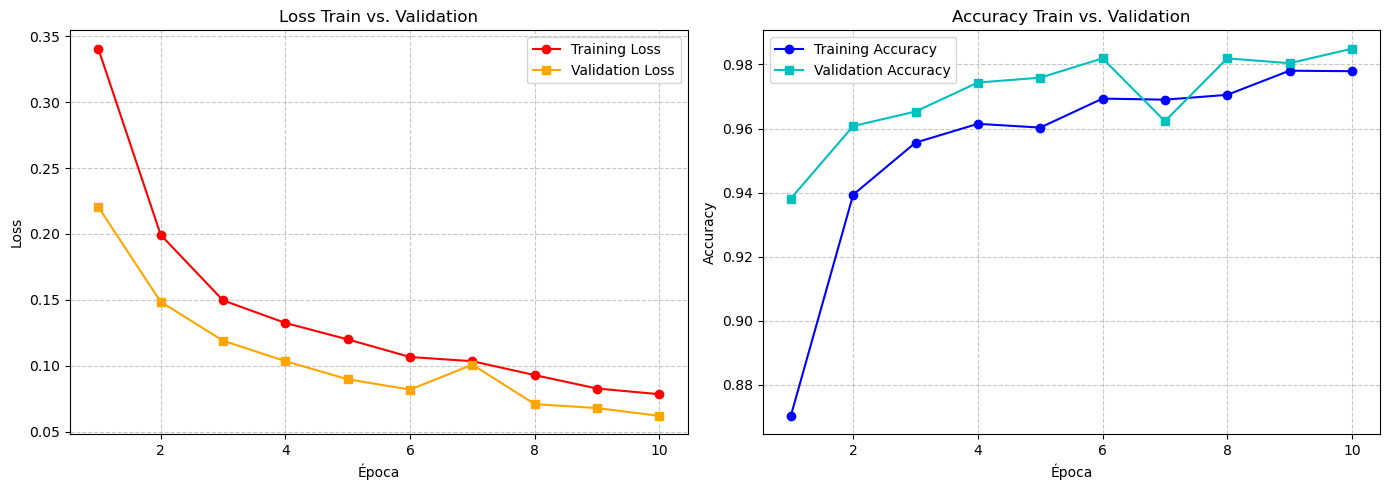

In [12]:
# Training the model:
train = True

if train:
    loss_hist_train, acc_hist_train, loss_hist_test, acc_hist_test = train_model(model_xception_pre, epochs=10, save_dir = '../models/pretrained/xception_casting_model_2.pth')
    plot_metrics(loss_hist_train, acc_hist_train, loss_hist_test, acc_hist_test)

In [13]:
# Loading the model for inference:
model_dir = '../models/pretrained/xception_casting_model_2.pth'
model_xception_pre.load_state_dict(torch.load(model_dir))

<All keys matched successfully>

--- Classification Report --- 
              precision    recall  f1-score   support

   def_front       0.99      0.99      0.99       453
    ok_front       0.99      0.98      0.98       262

    accuracy                           0.99       715
   macro avg       0.99      0.99      0.99       715
weighted avg       0.99      0.99      0.99       715



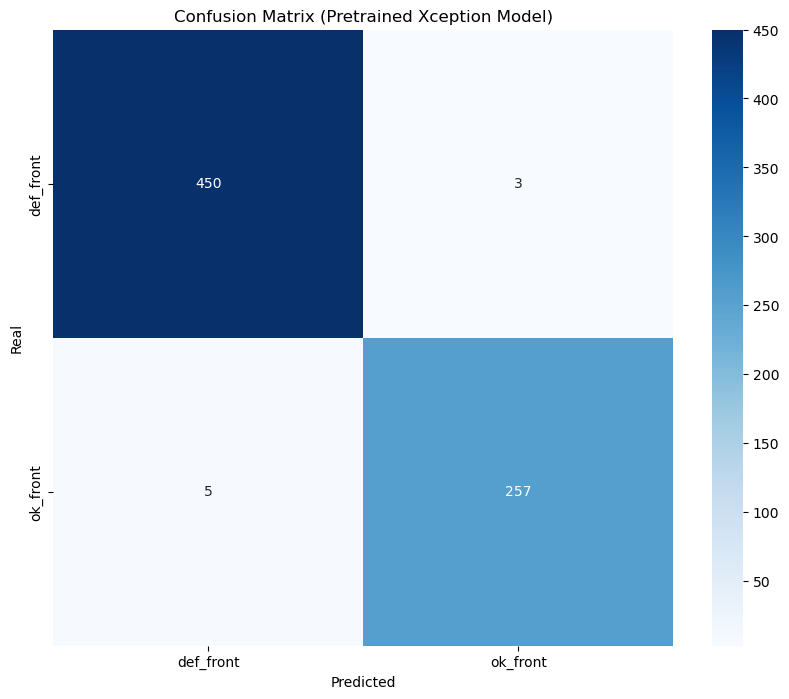

In [14]:
evaluation_inform(model_xception_pre, test_loader, device, classes, model_name="Pretrained Xception Model")

# 6.- Transfer Learning - Phase 2 (Controlled Fine Tuning ):

In [15]:
# Load the model with no pretrained weights:    
model_xception_no_pre = timm.create_model('xception', pretrained=False)
model_xception_no_pre.fc = nn.Linear(n_features, n_classes) # Replace the final layer with a new one that has the correct number of output classes
model_xception_no_pre = model_xception_no_pre.to(device)

c:\Users\estiv\.conda\envs\togProject\lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Epoch 1/10 | Train Loss: 0.6249 | Train Accuracy: 66.21% | Val Loss: 0.5369 | Val Accuracy: 73.30%
Epoch 2/10 | Train Loss: 0.5256 | Train Accuracy: 77.45% | Val Loss: 0.4780 | Val Accuracy: 81.15%
Epoch 3/10 | Train Loss: 0.4859 | Train Accuracy: 79.15% | Val Loss: 0.5101 | Val Accuracy: 79.19%
Epoch 4/10 | Train Loss: 0.4530 | Train Accuracy: 82.48% | Val Loss: 0.4342 | Val Accuracy: 82.81%
Epoch 5/10 | Train Loss: 0.4263 | Train Accuracy: 84.15% | Val Loss: 0.4223 | Val Accuracy: 82.96%
Epoch 6/10 | Train Loss: 0.4277 | Train Accuracy: 83.60% | Val Loss: 0.3963 | Val Accuracy: 85.22%
Epoch 7/10 | Train Loss: 0.4046 | Train Accuracy: 84.66% | Val Loss: 0.3991 | Val Accuracy: 84.16%
Epoch 8/10 | Train Loss: 0.3881 | Train Accuracy: 85.39% | Val Loss: 0.3986 | Val Accuracy: 84.77%
Epoch 9/10 | Train Loss: 0.4001 | Train Accuracy: 83.90% | Val Loss: 0.3786 | Val Accuracy: 84.92%
Epoch 10/10 | Train Loss: 0.3743 | Train Accuracy: 85.86% | Val Loss: 0.3709 | Val Accuracy: 86.12%


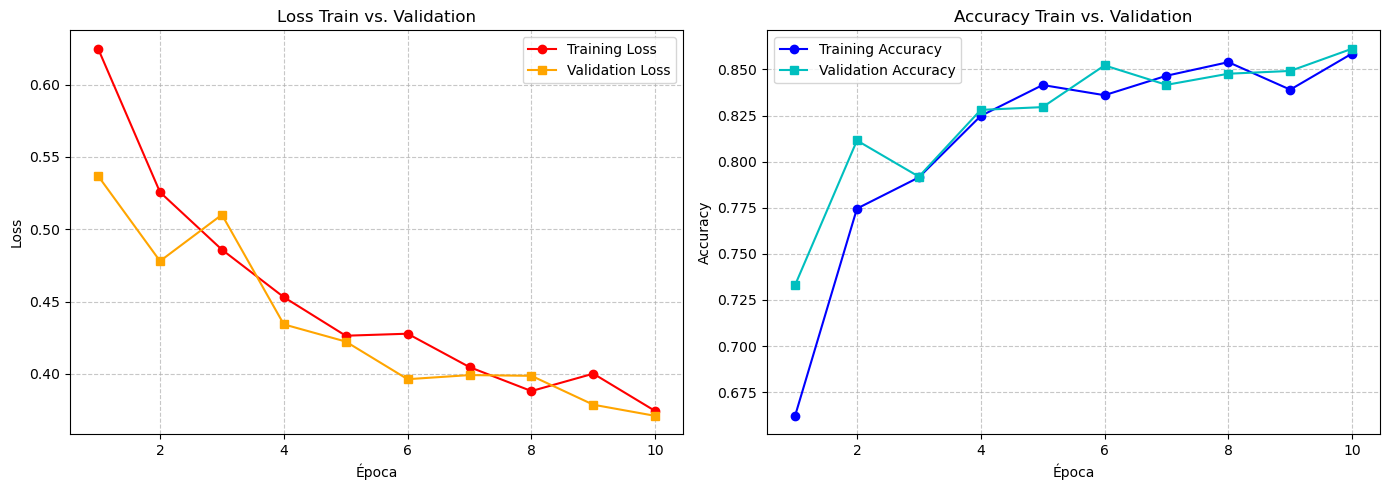

In [16]:
# Training the model:
train = True

if train:
    loss_hist_train, acc_hist_train, loss_hist_test, acc_hist_test = train_model(model_xception_no_pre, epochs=10, save_dir = '../models/no_pretrained/xception_casting_model_no_pre_2.pth')
    plot_metrics(loss_hist_train, acc_hist_train, loss_hist_test, acc_hist_test)

In [17]:
model_dir = '../models/no_pretrained/xception_casting_model_no_pre_2.pth'
model_xception_no_pre.load_state_dict(torch.load(model_dir))

<All keys matched successfully>

--- Classification Report --- 
              precision    recall  f1-score   support

   def_front       0.88      0.92      0.90       453
    ok_front       0.86      0.79      0.82       262

    accuracy                           0.88       715
   macro avg       0.87      0.86      0.86       715
weighted avg       0.87      0.88      0.87       715



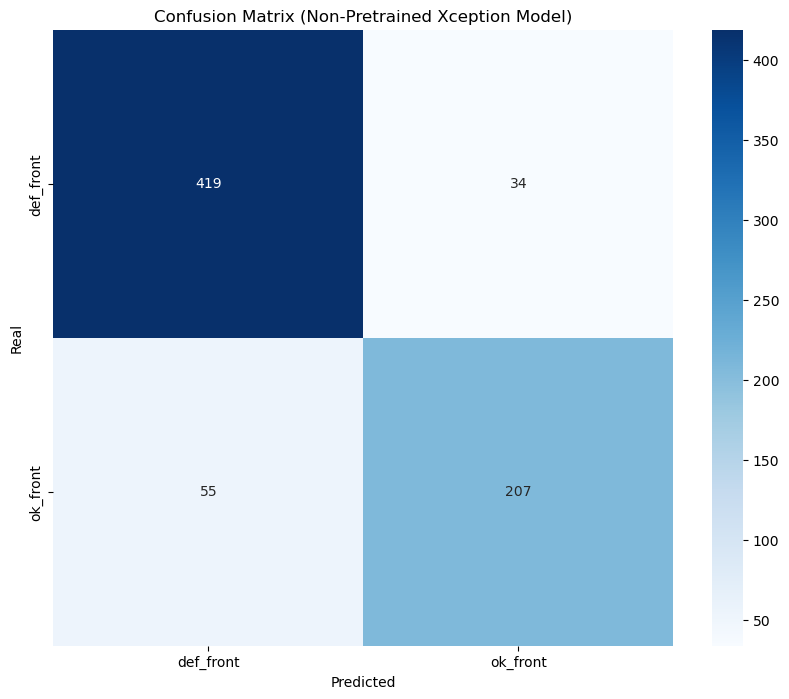

In [18]:
evaluation_inform(model_xception_no_pre, test_loader, device, classes, model_name="Non-Pretrained Xception Model")

# 8.- Final Evaluation and Diagnosis

## 8.1. Comparison vs. Baseline (Non-Pretrained Model)
* **Did the model improve compared to the baseline?** Yes, a highly significant improvement is observed across all metrics.
* **By how much?** There was an increase from 88% to 99% in overall Accuracy. When comparing class-specific performance, the baseline model struggled significantly with the minority class (`ok_front`), achieving a Recall of only 0.79. In contrast, the pretrained model successfully classified 98% of the `ok_front` parts correctly. The overall Macro F1-Score jumped from 0.86 (baseline) to 0.99 (pretrained), demonstrating a much more robust understanding of the features.

## 8.2. Overfitting and Generalization Analysis
* **Pretrained Model (Transfer Learning):** No significant overfitting is evident. The model demonstrates exceptional generalization, maintaining a Macro F1-Score of 0.99 on unseen data. It successfully learned the structural characteristics of the defects.

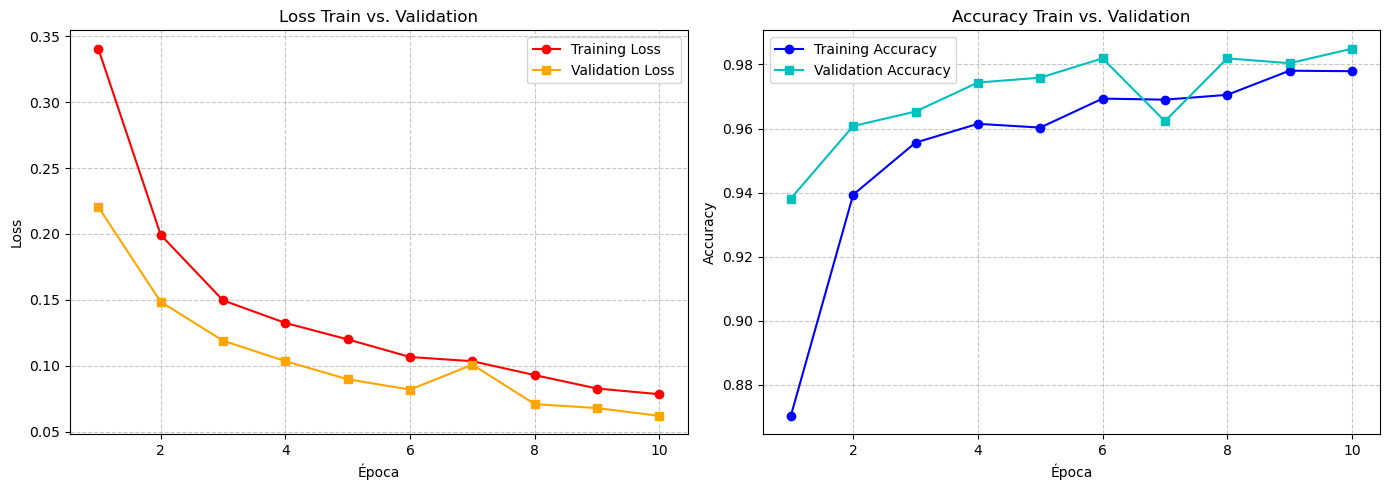

* **Non-Pretrained Model (Baseline):** While not necessarily heavily overfitted, it shows clear signs of underperformance and instability compared to the pretrained version. Its lower precision (0.86) and recall (0.79) for the `ok_front` class indicate that, without prior weight initialization, the network lacked the capacity to reliably extract complex metallurgical features within the same number of epochs.

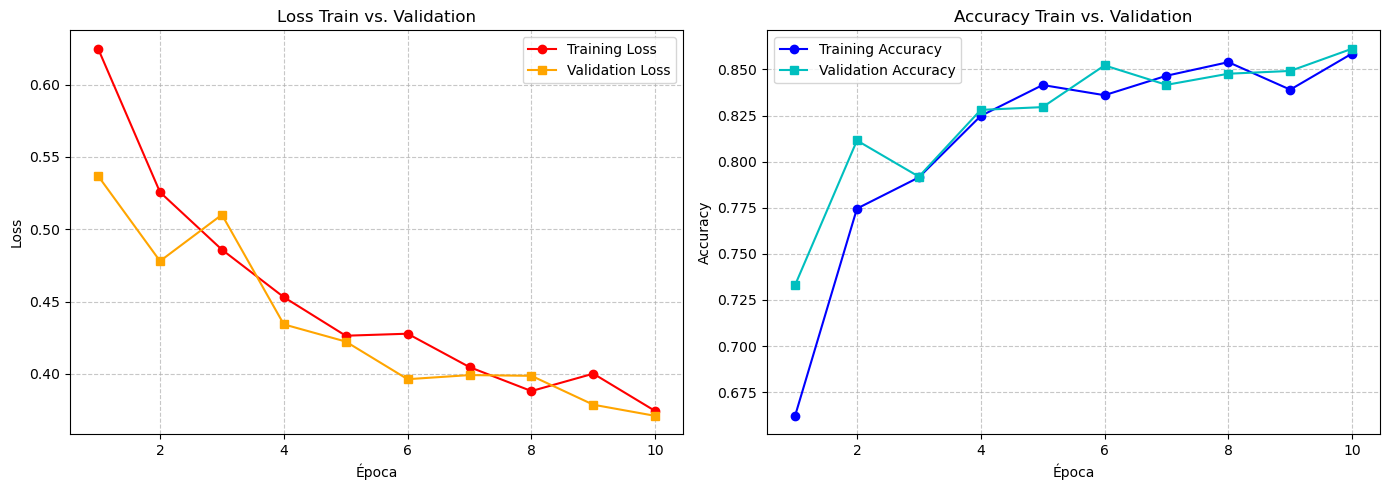

## 8.3. Key Design Decisions
* **What decisions were key to the performance gap between both models?**
    * **Transfer Learning (ImageNet Weights):** This was the absolute defining factor. Starting from a model with a mature capacity for extracting visual features (edges, textures) allowed the pretrained model to reach 99% accuracy, whereas the baseline model plateaued at 88%.
    * **Data Augmentation:** It proved fundamental to simulate part variability. However, it was much more effectively leveraged by the pretrained model, which already possessed baseline feature recognition capabilities.
    * **Fine-Tuning Strategy:** Replacing the classification head while keeping the base structure stable allowed the pretrained model to adapt to the industrial domain seamlessly, avoiding the convergence struggles seen in the non-pretrained model.

## 8.4. Test Set Report
* **Primary Metric Chosen: F1-Score** * *Justification:* Due to the class imbalance (453 defective vs. 262 OK), relying exclusively on Accuracy can be misleading. The F1-Score evaluates Precision and Recall jointly. The pretrained model achieved an excellent balance (F1 of 0.99 for defects and 0.98 for OK parts), whereas the baseline showed a concerning bias, dropping its F1-Score to 0.82 for the OK parts.

### Confusion Matrix Analysis (Analytical reconstruction based on metrics)

To understand the operational impact in a real manufacturing environment, the analytical reconstruction of the confusion matrices for both models is compared below:

#### Model 1: Non-Pretrained Baseline (Accuracy: 88%)
* **True Positives (`def_front` correctly classified):** 419
* **True Negatives (`ok_front` correctly classified):** 207
* **False Positives (`ok_front` part classified as `def_front`):** 55
    * *Operational impact:* High rate of false alarms. 55 good parts would be sent for unnecessary manual review, wasting operational time.
* **False Negatives (`def_front` part classified as `ok_front`):** 34
    * *Operational impact:* Critical failure. 36 defective parts would bypass the quality filter and reach the customer.

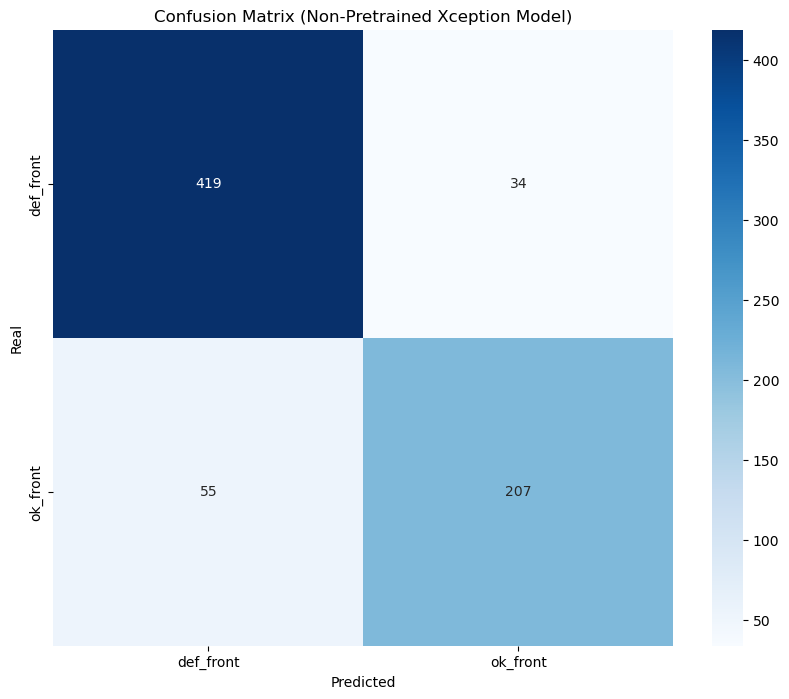

#### Model 2: Pretrained Xception (Accuracy: 99%)
* **True Positives (`def_front` correctly classified):** 450
* **True Negatives (`ok_front` correctly classified):** ~257
* **False Positives (`ok_front` part classified as `def_front`):** ~5
    * *Operational impact:* Drastic improvement. Only 5 good parts generate false alarms, representing a highly acceptable margin in an industrial setting.
* **False Negatives (`def_front` part classified as `ok_front`):** ~3
    * *Operational impact:* The main operational risk is reduced to an absolute minimum. Only 5 defective parts bypassed the filter (compared to 36 in the baseline). Future iterations could aim to eliminate these last few errors through strict threshold tuning.

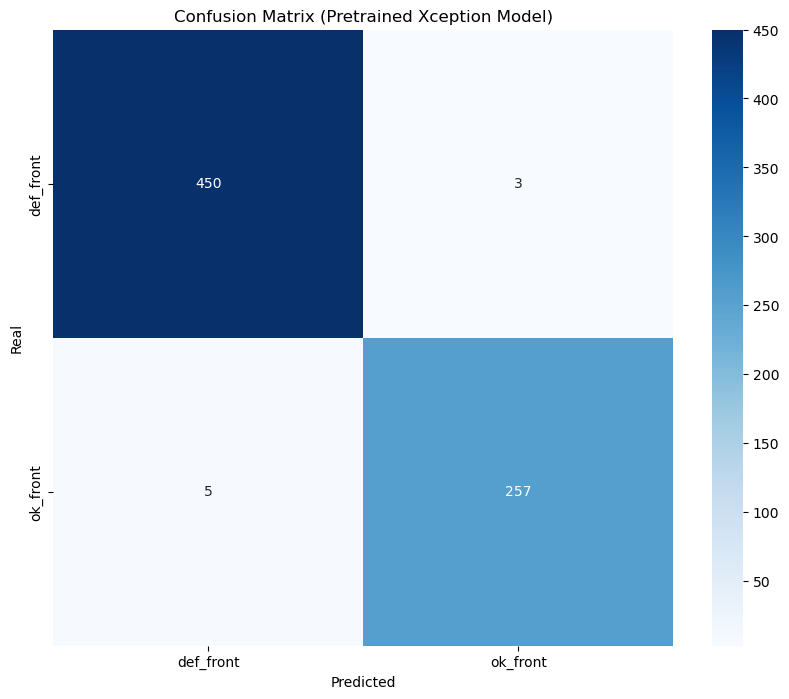

# 9.- Conclusions

**What worked:** The use of Transfer Learning with the Xception architecture (ImageNet weights) proved to be the most accurate decision, successfully extracting complex features with high precision and significantly outperforming the *baseline* model trained from scratch.

**What didn't work:** Counterintuitively, it was observed that **both models performed significantly better without applying *Data Augmentation***. It is important to note that the results presented in this evaluation correspond to the models trained without augmentation, as applying these techniques yielded very poor results. It is highly probable that aggressive transformations (such as rotations or spatial cropping) distorted the critical morphology of the casting defects, introducing noise instead of useful variability for the network. 

**What would be done differently:** For future iterations, drastic geometric augmentations will be discarded, limiting preprocessing exclusively to standard normalization or subtle lighting adjustments. Furthermore, a mathematical adjustment of the decision threshold (*threshold tuning*) will be implemented, focused strictly on reducing the false negative rate to zero, thereby mitigating the operational risk of approving defective parts for the customer.